BFS STARTING...


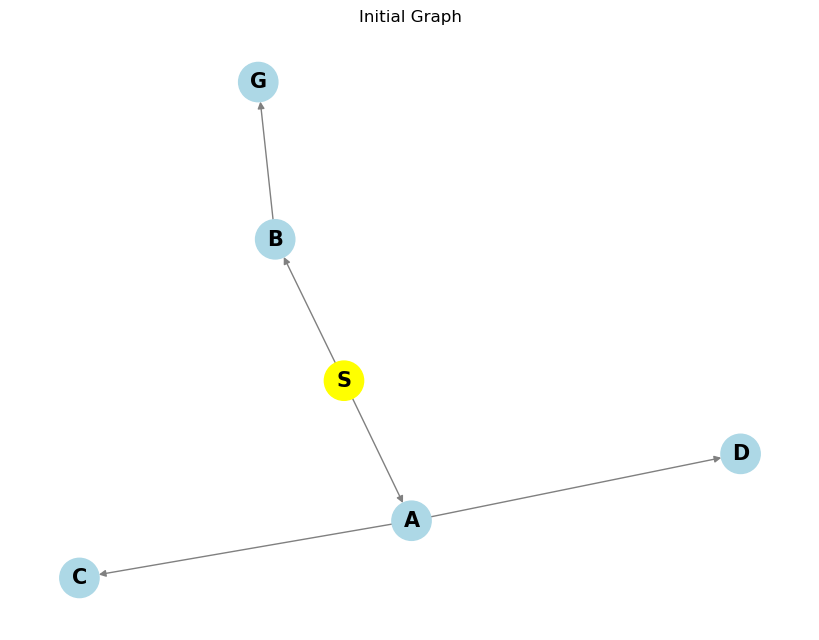


Step 1: Checking S


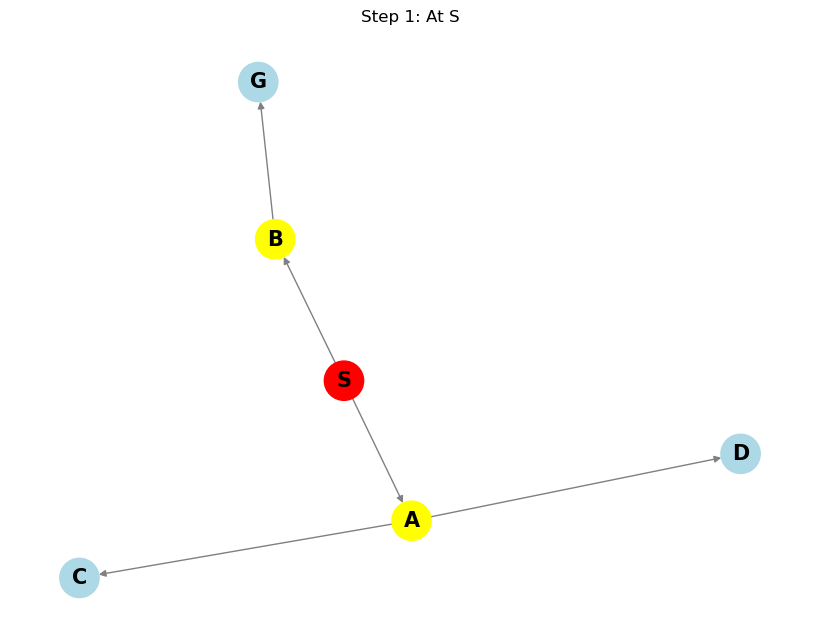


Step 2: Checking A


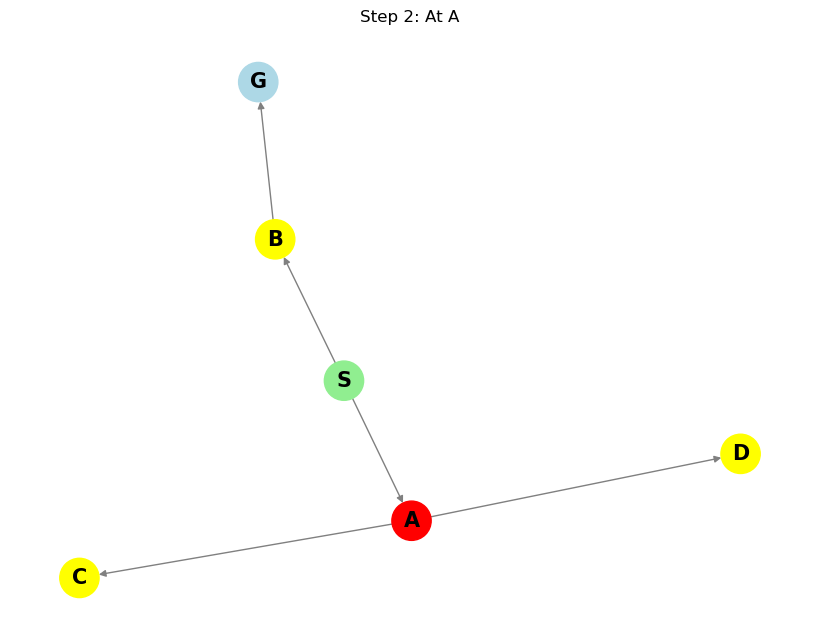


Step 3: Checking B


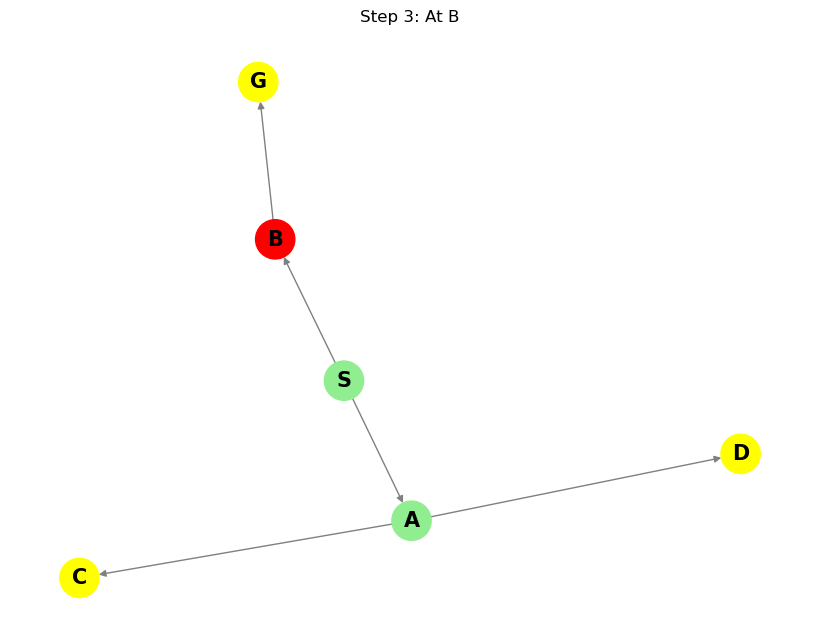


Step 4: Checking C


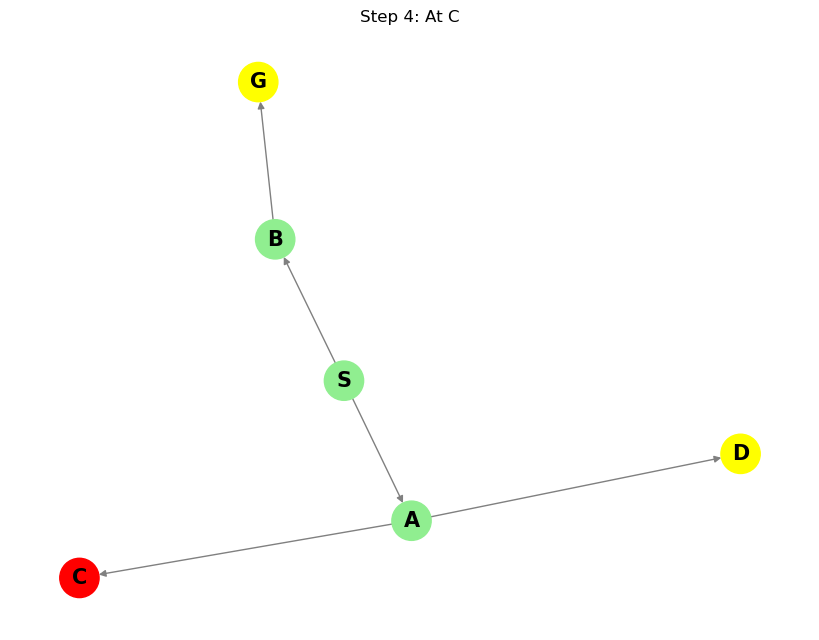


Step 5: Checking D


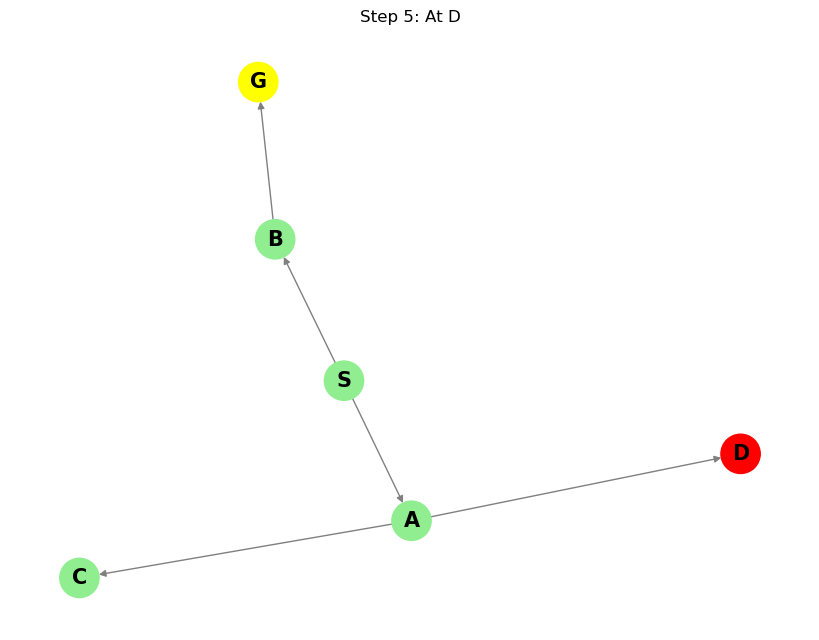


Step 6: Checking G
GOAL FOUND at G!


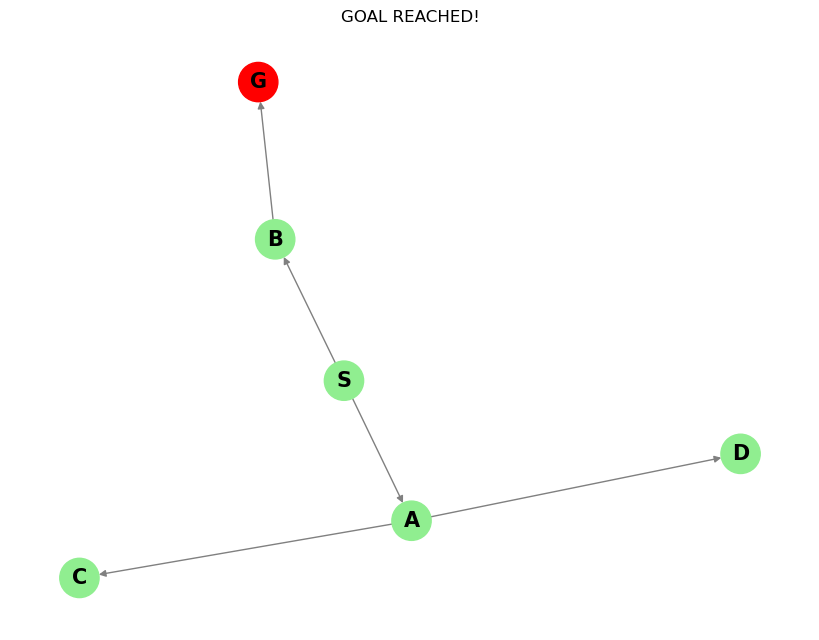


Path: S → B → G


In [21]:
#Task 01
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'S' : ['A', 'B'],
    'A' : ['C', 'D'],
    'B' : ['G'],
    'C' : [],
    'D' : [],
    'G' : []    
}

def show_graph(step_name, graph, visited=set(), current=None, frontier=[]):
    G = nx.DiGraph()
    for node in graph:
        for neighbor in graph[node]:
            G.add_edge(node, neighbor)
    
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    
    colors = []
    for node in G.nodes():
        if node == current:
            colors.append('red')
        elif node in visited:
            colors.append('lightgreen')
        elif node in frontier:
            colors.append('yellow')
        else:
            colors.append('lightblue')
    
    nx.draw(G, pos, with_labels=True, node_color=colors, 
            node_size=800, font_size=15, font_weight='bold',
            arrows=True, edge_color='gray')
    
    plt.title(step_name)
    plt.show()

start = 'S'
goal = 'G'
frontier = deque([start])
visited = set()
step = 1

show_graph("Initial Graph", graph, visited, None, [start])

while frontier:
    current = frontier.popleft()
    print(f"\nStep {step}: Checking {current}")
    
    if current == goal:
        print(f"GOAL FOUND at {current}!")
        show_graph("GOAL REACHED!", graph, visited, current, frontier)
        break
    
    if current not in visited:
        visited.add(current)
        for neighbor in graph[current]:
            if neighbor not in visited and neighbor not in frontier:
                frontier.append(neighbor)
    
    show_graph(f"Step {step}: At {current}", graph, visited, current, frontier)
    step += 1

print("\nPath: S → B → G")

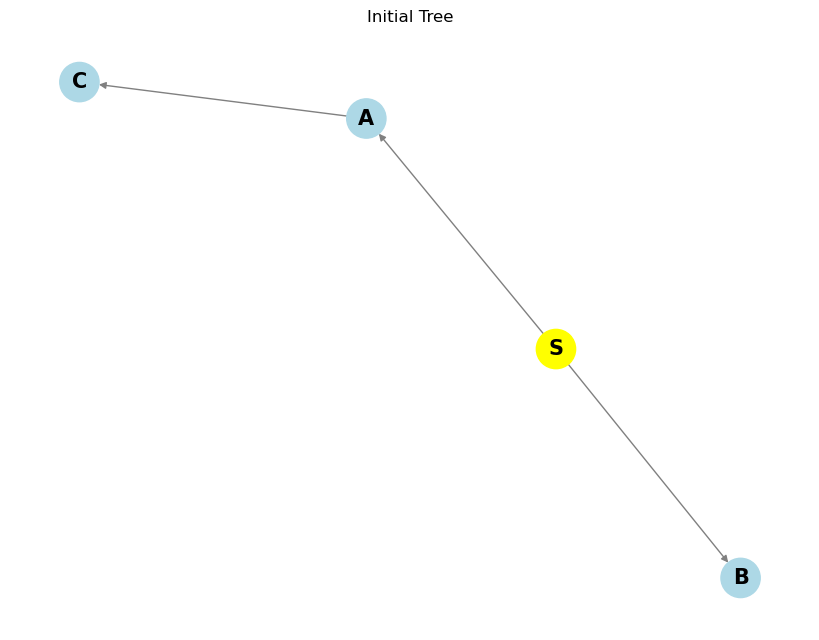


 Step 1: Visiting S


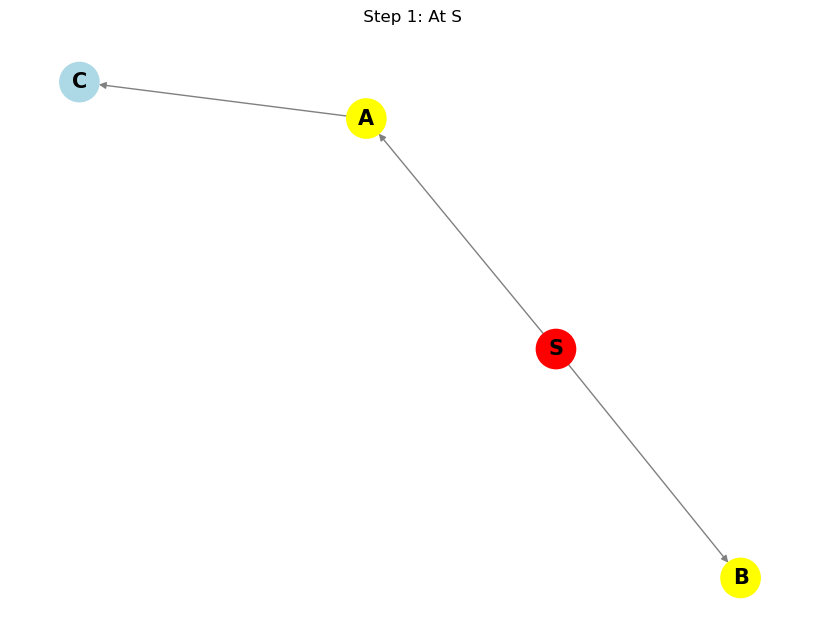


 Step 2: Visiting A


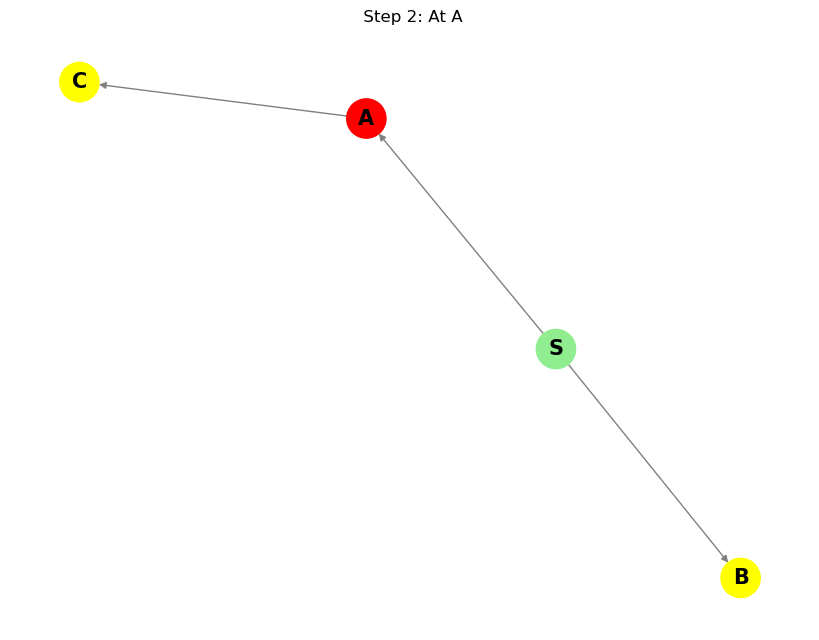


 Step 3: Visiting B


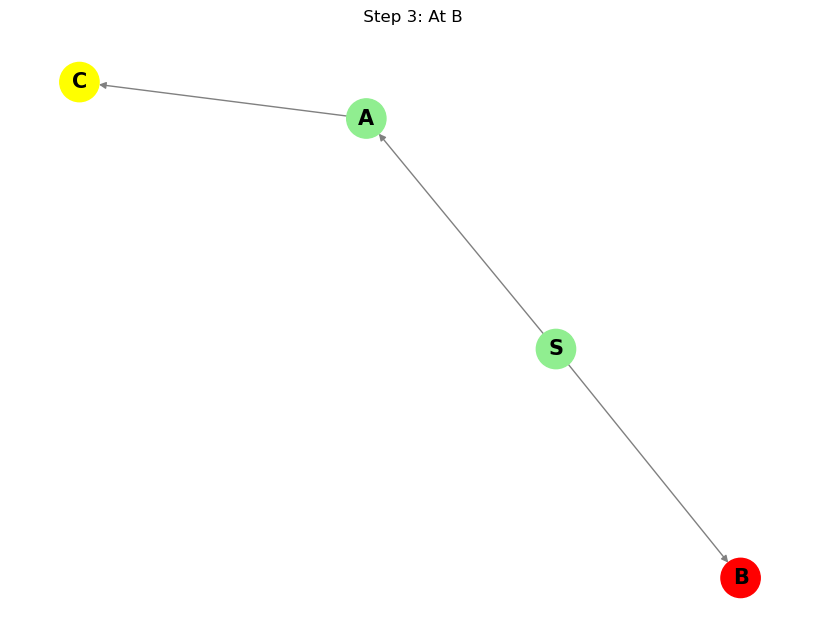


 Step 4: Visiting C
 GOAL FOUND at C!
 Path: S → A → C


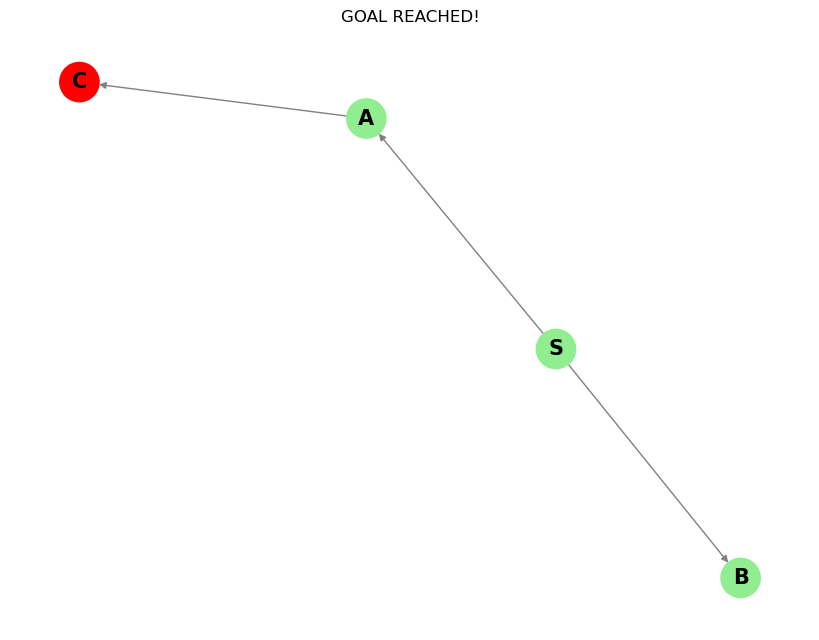

In [22]:
#Task 02 part 01
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

tree = {
    'S': ['A', 'B'],
    'A': ['C'],
    'B': [],
    'C': []
}

def show_tree(step_name, tree, visited=set(), current=None, frontier=[]):
    G = nx.DiGraph()
    for node in tree:
        for neighbor in tree[node]:
            G.add_edge(node, neighbor)
    
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    
    colors = []
    for node in G.nodes():
        if node == current:
            colors.append('red')
        elif node in visited:
            colors.append('lightgreen')
        elif node in frontier:
            colors.append('yellow')
        else:
            colors.append('lightblue')
    
    nx.draw(G, pos, with_labels=True, node_color=colors, 
            node_size=800, font_size=15, font_weight='bold',
            arrows=True, edge_color='gray')
    
    plt.title(step_name)
    plt.show()

def bfs_tree(start, goal):
    queue = deque([start])
    parent = {start: None}
    visited = set()
    frontier = [start]
    step = 1
    
    show_tree("Initial Tree", tree, visited, None, frontier)
    
    while queue:
        current = queue.popleft()
        frontier.remove(current)
        print(f"\n Step {step}: Visiting {current}")
        
        if current == goal:
            print(f" GOAL FOUND at {current}!")
            
            path = []
            node = current
            while node:
                path.append(node)
                node = parent[node]
            path.reverse()
            print(f" Path: {' → '.join(path)}")
            
            visited.add(current)
            show_tree("GOAL REACHED!", tree, visited, current, frontier)
            return
        
        if current not in visited:
            visited.add(current)
            for neighbor in tree[current]:
                if neighbor not in visited:
                    parent[neighbor] = current
                    queue.append(neighbor)
                    frontier.append(neighbor)
        
        show_tree(f" Step {step}: At {current}", tree, visited, current, frontier)
        step += 1
    
    print("Goal not found!")

bfs_tree('S', 'C')

In [18]:
#Task 02 part 02
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'S': ['A', 'B'],
    'A': ['C'],
    'B': ['C'],  
    'C': ['B'] 
}

def show_graph(step_name, graph, current=None, queue=[], visited=set()):
    G = nx.DiGraph()
    for node in graph:
        for neighbor in graph[node]:
            G.add_edge(node, neighbor)
    
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    
    colors = []
    for node in G.nodes():
        if node == current:
            colors.append('red')
        elif node in queue:
            colors.append('yellow')
        elif node in visited:
            colors.append('lightgreen')
        else:
            colors.append('lightblue')
    
    nx.draw(G, pos, with_labels=True, node_color=colors, 
            node_size=800, font_size=15, font_weight='bold',
            arrows=True, edge_color='gray')
    
    plt.title(step_name)
    plt.show()

def bfs_graph_no_visited(start, max_steps=10):
    queue = deque([start])
    visited = set()
    step = 1
    
    print("BFS WITHOUT VISITED CHECK...")
    print("(This will loop forever in a cycle!)")
    show_graph("Initial Graph", graph, None, [start], visited)
    
    while queue and step <= max_steps:
        current = queue.popleft()
        
        print(f"\nStep {step}: Visiting {current}")
        print(f"Queue: {list(queue)}")
        
        visited.add(current)
        
        for neighbor in graph[current]:
            queue.append(neighbor)
            print(f"Added {neighbor} to queue")
        
        show_graph(f"Step {step}: At {current}", graph, current, list(queue), visited)
        step += 1

    print("\n Stopped — would loop forever!")
    show_graph("Final State (Before Infinite Loop)", graph, None, list(queue), visited)

bfs_graph_no_visited('S')

Step 1: Visiting S
Step 2: Visiting A
Step 3: Visiting B
Step 4: Visiting C
Step 5: Visiting C
Step 6: Visiting B
Step 7: Visiting B
Step 8: Visiting C
Step 9: Visiting C
Step 10: Visiting B
Stopped — would loop forever!


BFS STARTING...


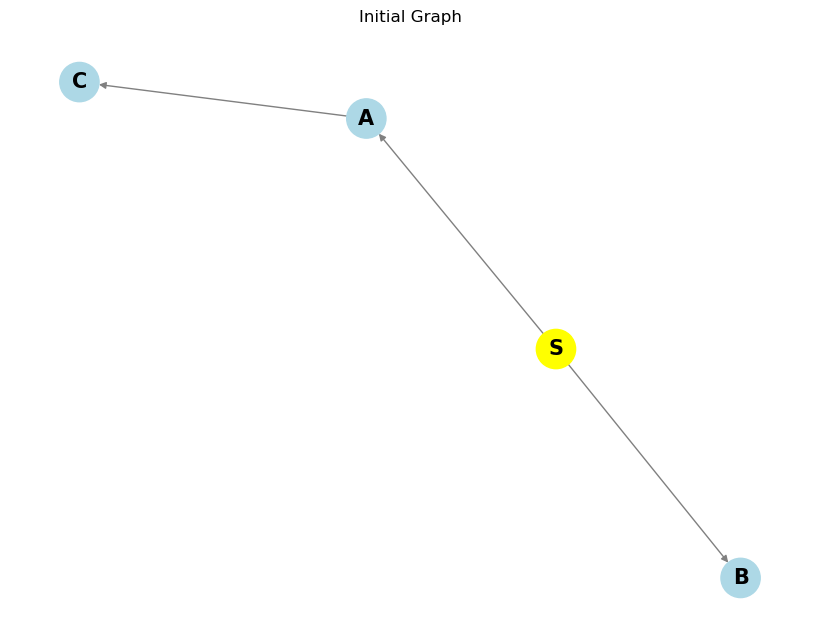


Step 1: Visiting S


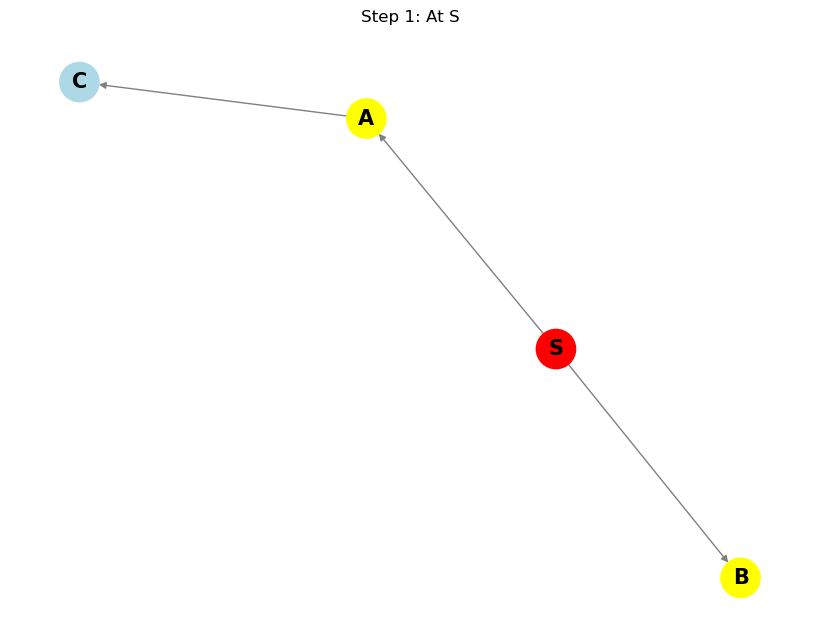


Step 2: Visiting A


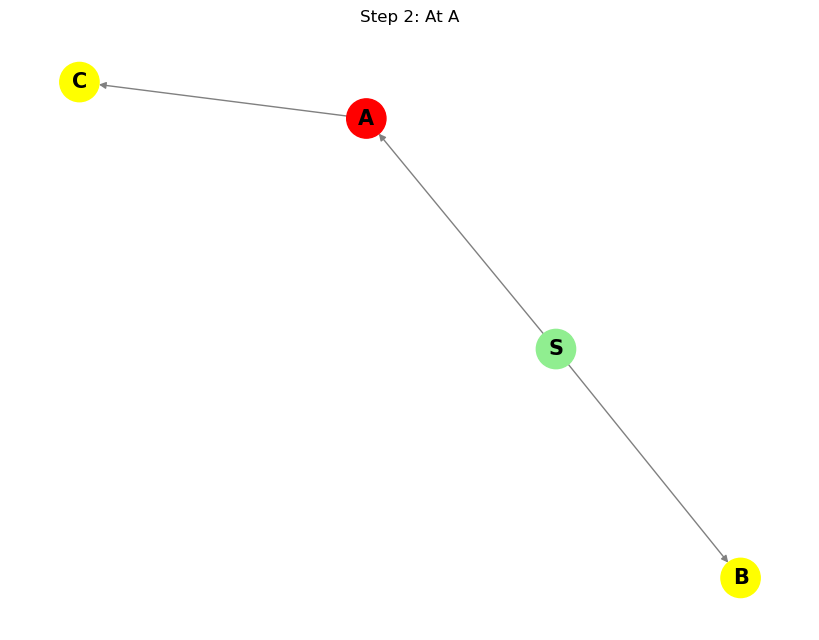


Step 3: Visiting B


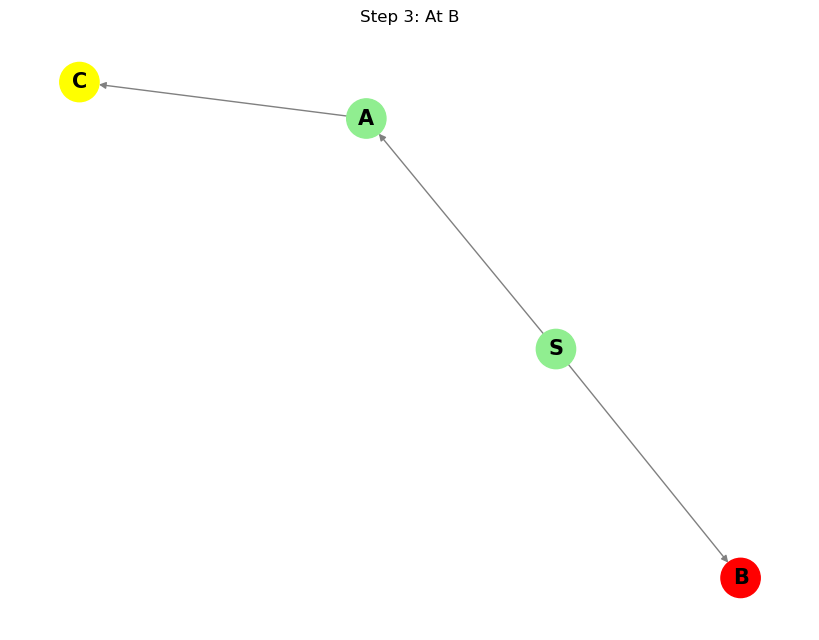


Step 4: Visiting C
Goal found! Path: S → A → C


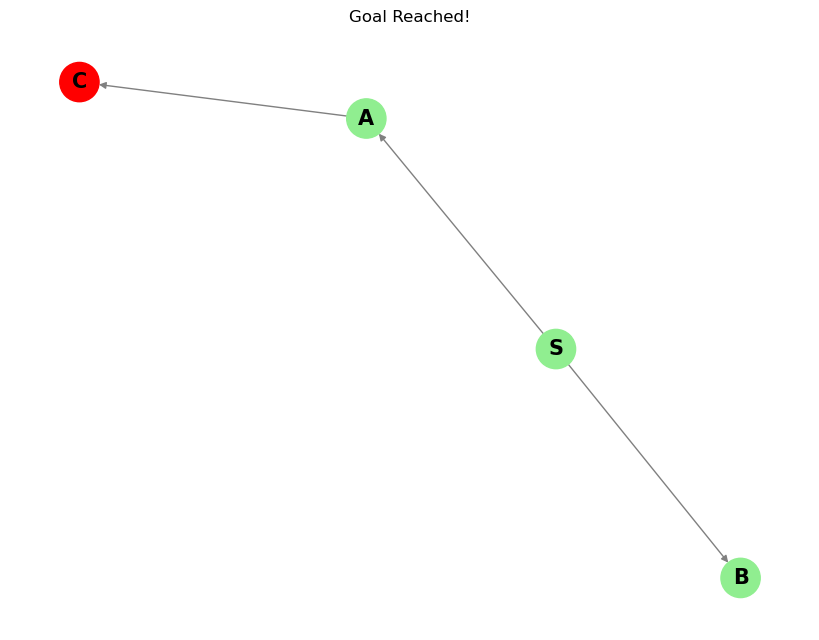

In [23]:
#Task 02 part 3
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'S': ['A', 'B'],
    'A': ['C'],
    'B': [],
    'C': []
}

def show_graph(step_name, graph, visited=set(), current=None, frontier=[]):
    G = nx.DiGraph()
    for node in graph:
        for neighbor in graph[node]:
            G.add_edge(node, neighbor)
    
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    
    colors = []
    for node in G.nodes():
        if node == current:
            colors.append('red')
        elif node in visited:
            colors.append('lightgreen')
        elif node in frontier:
            colors.append('yellow')
        else:
            colors.append('lightblue')
    
    nx.draw(G, pos, with_labels=True, node_color=colors, 
            node_size=800, font_size=15, font_weight='bold',
            arrows=True, edge_color='gray')
    
    plt.title(step_name)
    plt.show()

def bfs_graph_with_visited(start, goal):
    queue = deque([start])
    visited = set()
    parent = {start: None}
    frontier = [start]
    step = 1
    
    print("BFS STARTING...")
    show_graph("Initial Graph", graph, visited, None, frontier)
    
    while queue:
        current = queue.popleft()
        frontier.remove(current)
        
        if current in visited:
            print(f"\nStep {step}: Skipping {current} - already visited")
            show_graph(f"Step {step}: Skipping {current}", graph, visited, current, frontier)
            step += 1
            continue

        print(f"\nStep {step}: Visiting {current}")
        visited.add(current)

        if current == goal:
            path = []
            node = current
            while node:
                path.append(node)
                node = parent[node]
            path.reverse()
            print(f"Goal found! Path: {' → '.join(path)}")
            show_graph("Goal Reached!", graph, visited, current, frontier)
            return

        for neighbor in graph[current]:
            if neighbor not in parent:
                parent[neighbor] = current
            queue.append(neighbor)
            frontier.append(neighbor)
        
        show_graph(f"Step {step}: At {current}", graph, visited, current, frontier)
        step += 1
    
    print("Goal not found!")

bfs_graph_with_visited('S', 'C')

DFS STARTING...


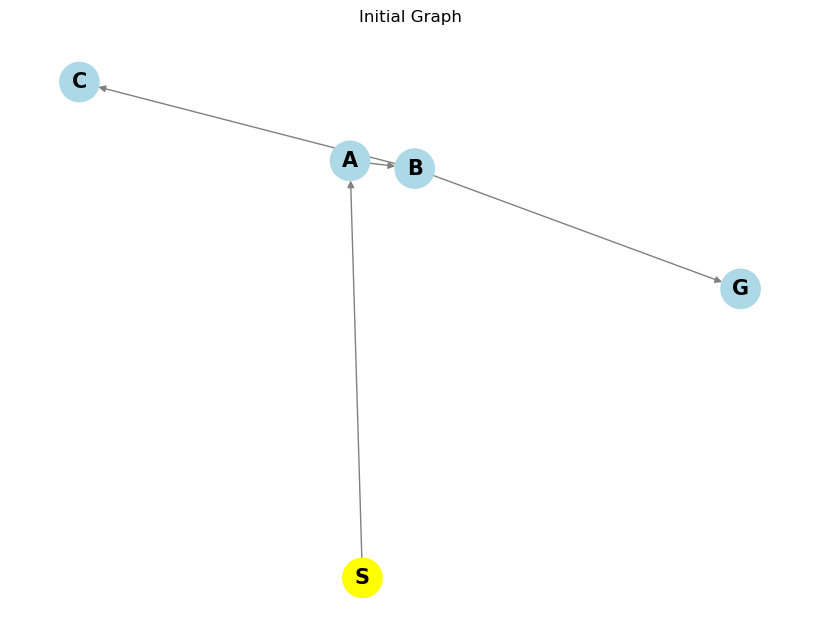


Step 1: Popped S from stack
Stack: []
Visiting: S
Added A to stack


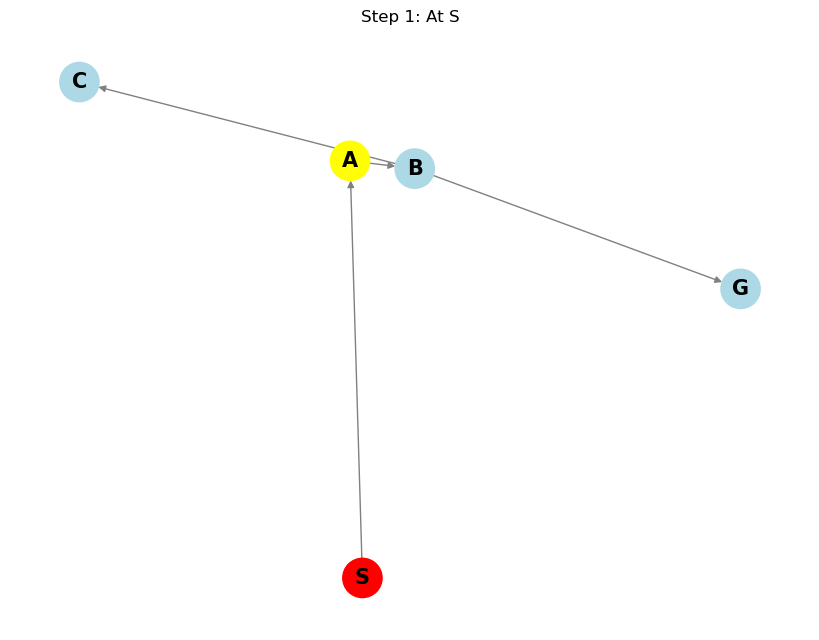


Step 2: Popped A from stack
Stack: []
Visiting: A
Added B to stack


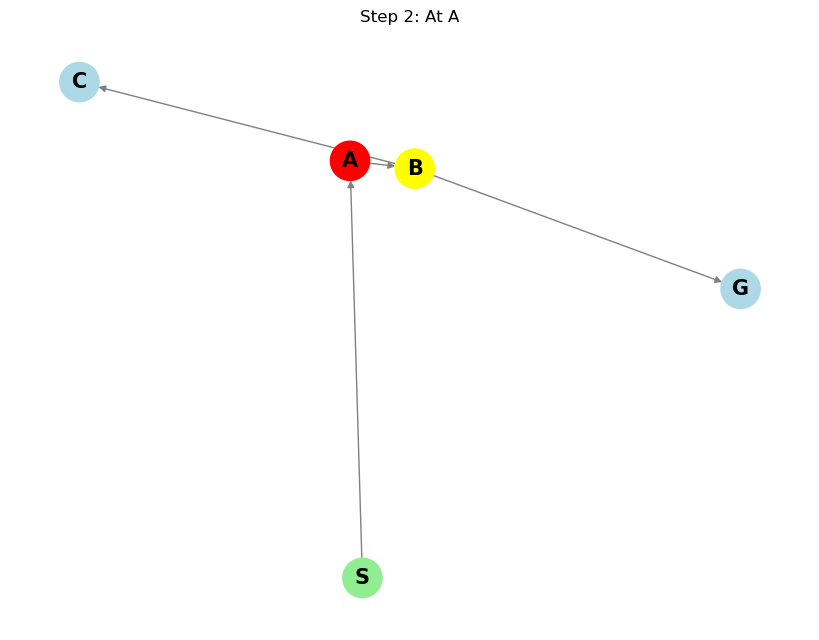


Step 3: Popped B from stack
Stack: []
Visiting: B
Added G to stack
Added C to stack


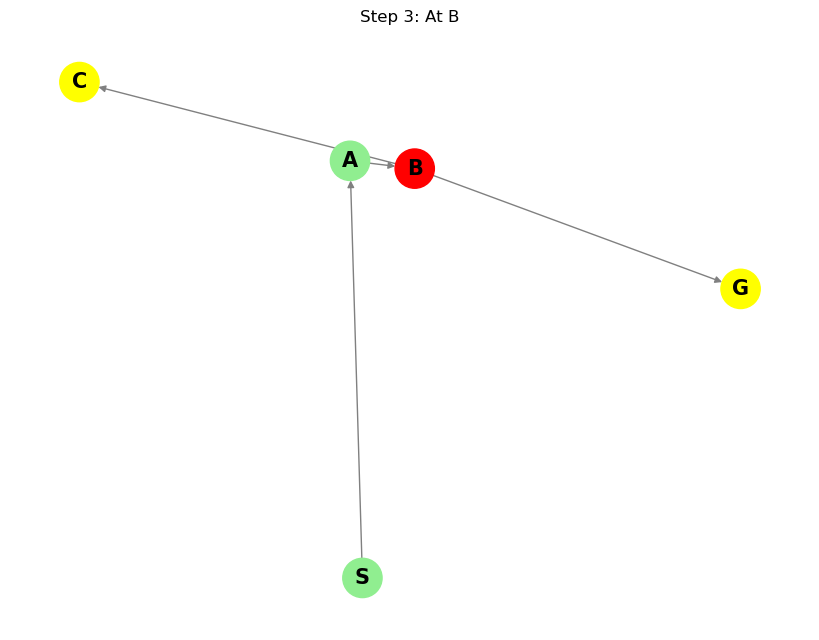


Step 4: Popped C from stack
Stack: ['G']
Visiting: C


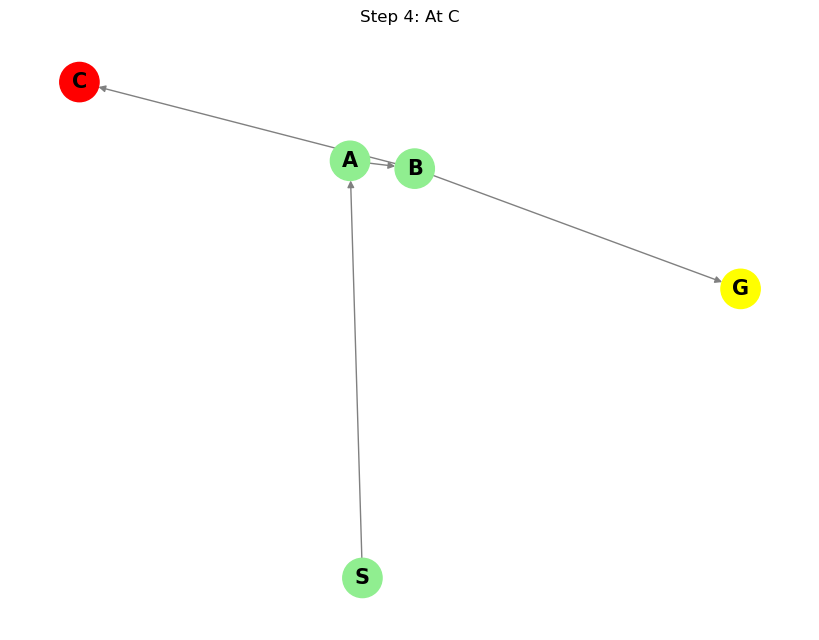


Step 5: Popped G from stack
Stack: []
Visiting: G

 Goal Found!


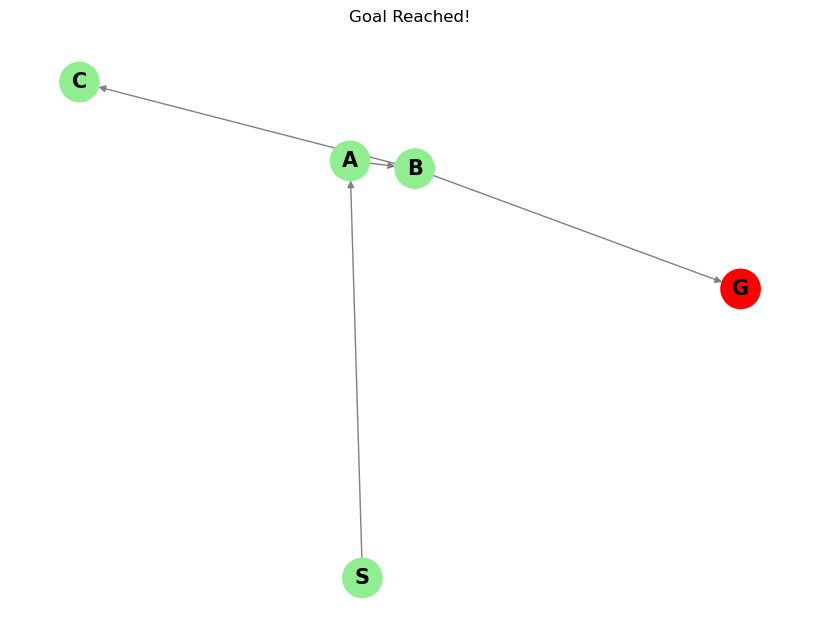


Traversal Path: S → A → B → C → G
Solution Path: S → A → B → G


In [24]:
#Task 03
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'S': ['A'],
    'A': ['B'],
    'B': ['C', 'G'],
    'C': [],
    'G': []
}

def show_graph(step_name, graph, visited=set(), current=None, stack=[]):
    G = nx.DiGraph()
    for node in graph:
        for neighbor in graph[node]:
            G.add_edge(node, neighbor)
    
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    
    colors = []
    for node in G.nodes():
        if node == current:
            colors.append('red')
        elif node in visited:
            colors.append('lightgreen')
        elif node in stack:
            colors.append('yellow')
        else:
            colors.append('lightblue')
    
    nx.draw(G, pos, with_labels=True, node_color=colors, 
            node_size=800, font_size=15, font_weight='bold',
            arrows=True, edge_color='gray')
    
    plt.title(step_name)
    plt.show()

def dfs(graph, start, goal):
    stack = [start]     
    visited = set()
    parent = {start: None}
    traversal_path = []
    step = 1
    
    print("DFS STARTING...")
    show_graph("Initial Graph", graph, visited, None, stack)
    
    while stack:
        current = stack.pop() 
        
        print(f"\nStep {step}: Popped {current} from stack")
        print(f"Stack: {stack}")

        if current in visited:
            print(f"Skipping {current} - already visited")
            show_graph(f"Step {step}: Skipping {current}", graph, visited, current, stack)
            step += 1
            continue

        print(f"Visiting: {current}")
        traversal_path.append(current)
        visited.add(current)

        if current == goal:
            print("\n Goal Found!")
            show_graph("Goal Reached!", graph, visited, current, stack)
            break
            
        for neighbor in reversed(graph[current]):
            if neighbor not in visited:
                parent[neighbor] = current
                stack.append(neighbor)
                print(f"Added {neighbor} to stack")
        
        show_graph(f"Step {step}: At {current}", graph, visited, current, stack)
        step += 1
    
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()
    
    print("\n" + "="*30)
    print(f"Traversal Path: {' → '.join(traversal_path)}")
    print(f"Solution Path: {' → '.join(path)}")
    print("="*30)

dfs(graph, 'S', 'G')

In [ ]:
#Task 04
import heapq
import networkx as nx
import matplotlib.pyplot as plt
edges = [
    ('S', 'A', 1),
    ('S', 'B', 5),
    ('A', 'G', 2),
    ('B', 'G', 1)
]

G = nx.Graph()

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

def uniform_cost_search(graph, start, goal):
    # priority queue: (cost, node, path)
    pq = []
    heapq.heappush(pq, (0, start, [start]))

    visited_cost = {}

    while pq:
        cost, node, path = heapq.heappop(pq)

        if node == goal:
            return path, cost

        if node in visited_cost and visited_cost[node] <= cost:
            continue

        visited_cost[node] = cost

        for neighbor in graph.neighbors(node):
            edge_cost = graph[node][neighbor]['weight']
            new_cost = cost + edge_cost
            heapq.heappush(pq, (new_cost, neighbor, path + [neighbor]))

    return None, float('inf')

start_node = 'S'
goal_node = 'G'

path, total_cost = uniform_cost_search(G, start_node, goal_node)

print("Optimal Path:", path)
print("Total Cost:", total_cost)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(6,5))
nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightgreen',
    node_size=2000,
    font_size=12,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Uniform Cost Search Graph")
plt.show()
